In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

from river import tree, model_selection, utils, metrics, stream
from river.compat import convert_river_to_sklearn

import itertools

import time

In [2]:
miniboone = fetch_openml(data_id=41150, as_frame=True, parser='auto')

# Extract features and targets
X = miniboone.data
y = miniboone.target

In [3]:
X.info()

#no null values
#all features are numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130064 entries, 0 to 130063
Data columns (total 50 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ParticleID_0   130064 non-null  float64
 1   ParticleID_1   130064 non-null  float64
 2   ParticleID_2   130064 non-null  float64
 3   ParticleID_3   130064 non-null  float64
 4   ParticleID_4   130064 non-null  float64
 5   ParticleID_5   130064 non-null  float64
 6   ParticleID_6   130064 non-null  float64
 7   ParticleID_7   130064 non-null  float64
 8   ParticleID_8   130064 non-null  float64
 9   ParticleID_9   130064 non-null  float64
 10  ParticleID_10  130064 non-null  float64
 11  ParticleID_11  130064 non-null  float64
 12  ParticleID_12  130064 non-null  float64
 13  ParticleID_13  130064 non-null  float64
 14  ParticleID_14  130064 non-null  float64
 15  ParticleID_15  130064 non-null  float64
 16  ParticleID_16  130064 non-null  float64
 17  ParticleID_17  130064 non-nul

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=5)

X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=5)

---
# Defining what 'a pass' means here


| Model          | Natural training unit                                     | What happens     |
| -------------- | --------------------------------------------------------- | ---------------------------------------- |
| Hoeffding tree | One complete sequential exposure to all training examples | Exactly (N) calls to `learn_one`      |
| XGBoost        | One boosting round, which adds one tree                   | The tree receives (N) bootstrap draws        |
| Random Forest  | One additional independently trained tree                 | Predictions/gradients are updated and one tree is added for binary classification |


---

### Hoeffding Tree



#### Hyperparameter tuning & its results:

In [5]:
ht_param_grid = {
    'grace_period': [50, 75, 100,125,150], 
    'max_depth': [1,2,3], 
    'split_criterion': ['gini', 'info_gain', 'hellinger'],
    'leaf_prediction': ['mc', 'nb', 'nba'],
    "delta": [1e-5, 1e-7, 1e-9],
    "tau": [0.01, 0.05, 0.1]
}

def HT_hyperparam_tuning(budget, X_train, y_train, pos_val, ht_param_grid=ht_param_grid):


    keys, values = zip(*ht_param_grid.items())
    combinations=[dict(zip(keys, v)) for v in itertools.product(*values)]
    
    models=[
        tree.HoeffdingTreeClassifier(**params)
        for params in combinations
    ]
    
    
    grid_search_stream = model_selection.SuccessiveHalvingClassifier(
        models=models,
        budget=budget, 
        eta=3,
        verbose=True,
        metric=metrics.ROCAUC(
            pos_val=pos_val,
            n_thresholds=100,
        )
    )
    
    for xi_dict, yi in stream.iter_array(X_train.values, y_train.values):
        grid_search_stream.learn_one(xi_dict, yi)
    
    #getting the best model
    best_model = grid_search_stream.best_model
    print("\n" + "="*50)
    print("TUNING COMPLETE")
    print("Best Found Tree Configuration:")
    print(f"Grace Period: {best_model.grace_period}")
    print(f"Max Depth: {best_model.max_depth}")
    print(f"Split Criterion: {best_model.split_criterion}")
    print(f"Leaf Prediction Strategy: {best_model.leaf_prediction}")
    print(f"Delta:{best_model.delta}")
    print(f"Tau:{best_model.tau}")

    return best_model


In [6]:
#ht_best_model=HT_hyperparam_tuning(budget=500000, X_train=X_train, y_train=y_train, pos_val=True, ht_param_grid=ht_param_grid)

In [7]:
def HT_hyperparam_val(POSITIVE_CLASS, X_val, y_val, best_model):

    validation_probabilities = []
    validation_targets = []
    
    validation_stream = stream.iter_array(
        X_val.to_numpy(),
        y_val.astype(str).to_numpy(),
    )
    
    for x_dict, y_true in validation_stream:
        probability_dict = best_model.predict_proba_one(x_dict)
    
        if POSITIVE_CLASS not in probability_dict:
            raise KeyError(
                f"Model did not return probability for class "
                f"{POSITIVE_CLASS!r}. Returned: {probability_dict}"
            )
    
        validation_probabilities.append(
            float(probability_dict[POSITIVE_CLASS])
        )
    
        validation_targets.append(
            int(y_true == POSITIVE_CLASS)
        )
    
    validation_probabilities = np.asarray(
        validation_probabilities,
        dtype=float,
    )
    
    validation_targets = np.asarray(
        validation_targets,
        dtype=int,
    )
    
    validation_auc = roc_auc_score(
        validation_targets,
        validation_probabilities,
    )
    
    print("Validation ROC-AUC:", validation_auc)
    print(
        "Probability range:",
        validation_probabilities.min(),
        validation_probabilities.max(),
    )
    print(
        "Probability standard deviation:",
        validation_probabilities.std(),
    )
    print(
        "Number of unique probabilities:",
        np.unique(
            np.round(validation_probabilities, decimals=10)
        ).size,
    )

In [8]:
#HT_hyperparam_val(POSITIVE_CLASS='True', X_val=X_val, y_val=y_val, best_model=ht_best_model)

#### Training a fresh model

In [9]:
FINAL_HT_PARAMS = {
    "grace_period": 50,
    "max_depth": 1,
    "split_criterion": "gini",
    "leaf_prediction": "mc",
    "delta": 1e-5,
    "tau": 0.01,
}

POSITIVE_CLASS = "True"

In [10]:
#preparing the train and val sets:

FEATURE_NAMES = list(X_train.columns)

X_train_array = X_train.to_numpy()
y_train_array = y_train.astype(str).to_numpy()

X_val_array = X_val.to_numpy()
y_val_array = y_val.astype(str).to_numpy()

In [11]:
#eval function
def evaluate_hoeffding_tree(
    model,
    X_eval: np.ndarray,
    y_eval: np.ndarray,
) -> dict:
    """Evaluate a River classifier using exact binary ROC-AUC."""

    probabilities = []
    binary_targets = []

    evaluation_stream = stream.iter_array(
        X_eval,
        y_eval,
        feature_names=FEATURE_NAMES,
        shuffle=False,
    )

    for row_number, (x_dict, y_true) in enumerate(
        evaluation_stream
    ):
        probability_dict = model.predict_proba_one(x_dict)

        if POSITIVE_CLASS not in probability_dict:
            raise KeyError(
                f"Positive class {POSITIVE_CLASS!r} missing "
                f"at evaluation row {row_number}. "
                f"Returned probabilities: {probability_dict}"
            )

        positive_probability = float(
            probability_dict[POSITIVE_CLASS]
        )

        probabilities.append(positive_probability)
        binary_targets.append(
            int(y_true == POSITIVE_CLASS)
        )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    binary_targets = np.asarray(
        binary_targets,
        dtype=int,
    )

    auc = roc_auc_score(
        binary_targets,
        probabilities,
    )

    brier = brier_score_loss(
        binary_targets,
        probabilities,
    )

    return {
        "roc_auc": float(auc),
        "brier_score": float(brier),
        "probability_rmse": float(np.sqrt(brier)),
        "probability_min": float(probabilities.min()),
        "probability_max": float(probabilities.max()),
        "unique_probabilities": int(
            np.unique(
                np.round(probabilities, decimals=12)
            ).size
        ),
    }

In [12]:
#shuffling dataset once:
CHECKPOINTS = list(range(1, 11))
MAX_PASSES = max(CHECKPOINTS)
ORDER_SEED = 42

rng = np.random.default_rng(ORDER_SEED)
training_order = rng.permutation(
    len(X_train_array)
)

X_train_ordered = X_train_array[training_order]
y_train_ordered = y_train_array[training_order]

In [13]:
#creating a fresh model:
ht_model = tree.HoeffdingTreeClassifier(
    **FINAL_HT_PARAMS
)

In [14]:
#running the passes:
ht_pass_results = []

cumulative_training_seconds = 0.0
cumulative_evaluation_seconds = 0.0
rows_processed = 0

for pass_number in range(1, MAX_PASSES + 1):

    # ---------------------------
    # One complete training pass
    # ---------------------------
    training_start = time.perf_counter()

    training_stream = stream.iter_array(
        X_train_ordered,
        y_train_ordered,
        feature_names=FEATURE_NAMES,
        shuffle=False,
    )

    for x_dict, y_true in training_stream:
        ht_model.learn_one(x_dict, y_true)
        rows_processed += 1

    pass_training_seconds = (
        time.perf_counter() - training_start
    )

    cumulative_training_seconds += (
        pass_training_seconds
    )

    if pass_number not in CHECKPOINTS:
        continue

    # ---------------------------
    # Validation evaluation
    # ---------------------------
    evaluation_start = time.perf_counter()

    evaluation = evaluate_hoeffding_tree(
        ht_model,
        X_val_array,
        y_val_array,
    )

    pass_evaluation_seconds = (
        time.perf_counter() - evaluation_start
    )

    cumulative_evaluation_seconds += (
        pass_evaluation_seconds
    )

    result = {
        "model": "Hoeffding Tree",
        "pass": pass_number,
        "rows_processed": rows_processed,
        "roc_auc": evaluation["roc_auc"],
        "brier_score": evaluation["brier_score"],
        "probability_rmse":
            evaluation["probability_rmse"],
        "unique_probabilities":
            evaluation["unique_probabilities"],
        "probability_min":
            evaluation["probability_min"],
        "probability_max":
            evaluation["probability_max"],
        "pass_training_seconds":
            pass_training_seconds,
        "cumulative_training_seconds":
            cumulative_training_seconds,
        "pass_evaluation_seconds":
            pass_evaluation_seconds,
        "cumulative_evaluation_seconds":
            cumulative_evaluation_seconds,
        "tree_height": getattr(
            ht_model,
            "height",
            None,
        ),
        "n_nodes": getattr(
            ht_model,
            "n_nodes",
            None,
        ),
        "n_leaves": getattr(
            ht_model,
            "n_leaves",
            None,
        ),
    }

    ht_pass_results.append(result)

    print(
        f"Pass {pass_number:>2} | "
        f"AUC={evaluation['roc_auc']:.6f} | "
        f"RMSE={evaluation['probability_rmse']:.6f} | "
        f"rows={rows_processed:,} | "
        f"train time={cumulative_training_seconds:.2f}s"
    )

Pass  1 | AUC=0.687026 | RMSE=0.392473 | rows=78,038 | train time=1.70s
Pass  2 | AUC=0.687026 | RMSE=0.392473 | rows=156,076 | train time=3.10s
Pass  3 | AUC=0.687026 | RMSE=0.392473 | rows=234,114 | train time=4.47s
Pass  4 | AUC=0.687026 | RMSE=0.392472 | rows=312,152 | train time=6.15s
Pass  5 | AUC=0.687026 | RMSE=0.392472 | rows=390,190 | train time=7.63s
Pass  6 | AUC=0.687026 | RMSE=0.392472 | rows=468,228 | train time=8.98s
Pass  7 | AUC=0.687026 | RMSE=0.392472 | rows=546,266 | train time=10.50s
Pass  8 | AUC=0.687026 | RMSE=0.392472 | rows=624,304 | train time=12.02s
Pass  9 | AUC=0.687026 | RMSE=0.392472 | rows=702,342 | train time=13.41s
Pass 10 | AUC=0.687026 | RMSE=0.392472 | rows=780,380 | train time=14.88s


In [15]:
ht_pass_results_df = pd.DataFrame(
    ht_pass_results
)

display(ht_pass_results_df)

,model,pass,rows_processed,roc_auc,brier_score,probability_rmse,unique_probabilities,probability_min,probability_max,pass_training_seconds,cumulative_training_seconds,pass_evaluation_seconds,cumulative_evaluation_seconds,tree_height,n_nodes,n_leaves
0,Hoeffding Tree,1,78038,0.687026,0.154035,0.392473,2,0.193047,0.829741,1.696764,1.696764,0.733907,0.733907,2,3,2
1,Hoeffding Tree,2,156076,0.687026,0.154035,0.392473,2,0.193161,0.829277,1.407912,3.104676,0.771823,1.505729,2,3,2
2,Hoeffding Tree,3,234114,0.687026,0.154035,0.392473,2,0.193200,0.829121,1.368180,4.472856,0.718396,2.224125,2,3,2
3,Hoeffding Tree,4,312152,0.687026,0.154035,0.392472,2,0.193219,0.829044,1.677287,6.150143,0.878148,3.102273,2,3,2
4,Hoeffding Tree,5,390190,0.687026,0.154035,0.392472,2,0.193230,0.828997,1.481726,7.631869,0.729247,3.831520,2,3,2
5,Hoeffding Tree,6,468228,0.687026,0.154035,0.392472,2,0.193238,0.828966,1.343402,8.975272,0.713356,4.544875,2,3,2
6,Hoeffding Tree,7,546266,0.687026,0.154035,0.392472,2,0.193243,0.828944,1.520297,10.495568,0.744529,5.289404,2,3,2
7,Hoeffding Tree,8,624304,0.687026,0.154035,0.392472,2,0.193248,0.828928,1.521886,12.017454,0.706987,5.996392,2,3,2
8,Hoeffding Tree,9,702342,0.687026,0.154035,0.392472,2,0.193251,0.828915,1.390833,13.408288,0.716373,6.712764,2,3,2
9,Hoeffding Tree,10,780380,0.687026,0.154035,0.392472,2,0.193253,0.828904,1.466763,14.875050,0.729060,7.441824,2,3,2


In [16]:
#saving results in a csv: 

ht_pass_results_df.to_csv(
    "MiniBooNE dataset outputs/hoeffding_tree_pass_results.csv",
    index=False,
)

In [17]:
def pass_roc_plot(df, model_name):

    plt.figure(figsize=(8, 5))

    plt.plot(
        df["pass"],
        df["roc_auc"],
        marker="o",
    )
    
    plt.xlabel("Number of complete training passes")
    plt.ylabel("Validation ROC-AUC")
    plt.title(f"{model_name}: ROC-AUC vs Training Passes")
    plt.xticks(CHECKPOINTS)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    

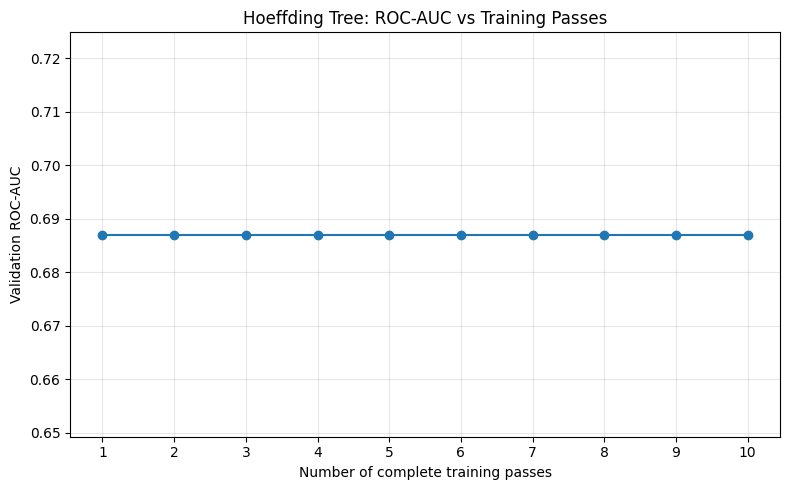

In [18]:
pass_roc_plot(df=ht_pass_results_df, model_name='Hoeffding Tree')

### Random Forest

In [19]:
#converting the label to binary for RF and XGB:

POSITIVE_LABEL = "True"

def make_binary_labels(y, positive_label="True"):
    """Convert the chosen positive label to 1 and all others to 0."""
    y_array = np.asarray(y).reshape(-1).astype(str)
    return (y_array == positive_label).astype(np.int8)


X_train_np = np.asarray(X_train, dtype=np.float32)
X_val_np = np.asarray(X_val, dtype=np.float32)

y_train_bin = make_binary_labels(
    y_train,
    positive_label=POSITIVE_LABEL,
)

y_val_bin = make_binary_labels(
    y_val,
    positive_label=POSITIVE_LABEL,
)

print("Training shape:", X_train_np.shape)
print("Validation shape:", X_val_np.shape)
print(
    "Training labels:",
    np.unique(y_train_bin, return_counts=True),
)
print(
    "Validation labels:",
    np.unique(y_val_bin, return_counts=True),
)

Training shape: (78038, 50)
Validation shape: (26013, 50)
Training labels: (array([0, 1], dtype=int8), array([56139, 21899]))
Validation labels: (array([0, 1], dtype=int8), array([18713,  7300]))


In [20]:
def evaluate_binary_probabilities(
    y_true,
    positive_probabilities,
):
    """Calculate exact ROC-AUC and probabilistic classification metrics."""
    y_true = np.asarray(y_true, dtype=np.int8)
    probabilities = np.asarray(
        positive_probabilities,
        dtype=np.float64,
    )

    if y_true.shape != probabilities.shape:
        raise ValueError(
            f"Shape mismatch: labels={y_true.shape}, "
            f"probabilities={probabilities.shape}"
        )

    if not np.all(np.isfinite(probabilities)):
        raise ValueError(
            "Predictions contain NaN or infinite values."
        )

    if np.any((probabilities < 0) | (probabilities > 1)):
        raise ValueError(
            "Predicted probabilities must lie between 0 and 1."
        )

    auc = roc_auc_score(
        y_true,
        probabilities,
    )

    brier = brier_score_loss(
        y_true,
        probabilities,
    )

    return {
        "roc_auc": float(auc),
        "brier_score": float(brier),
        "probability_rmse": float(np.sqrt(brier)),
        "probability_min": float(probabilities.min()),
        "probability_max": float(probabilities.max()),
        "probability_std": float(probabilities.std()),
        "unique_probabilities": int(
            np.unique(
                np.round(probabilities, decimals=12)
            ).size
        ),
    }

In [21]:
#hyperparameter tuning for RF
RF_TUNING_TREES = MAX_PASSES

rf_param_grid = {
    "criterion": [
        "gini",
        "entropy",
    ],
    "max_depth": [
        5,
        10,
        None,
    ],
    "min_samples_leaf": [
        1,
        5,
    ],
    "max_features": [
        "sqrt",
        None,
    ],
    "class_weight": [
        None,
        "balanced",
    ],
}

In [22]:
rf_configurations = list(
    ParameterGrid(rf_param_grid)
)

print(
    "Random Forest configurations:",
    len(rf_configurations),
)

Random Forest configurations: 48


In [ ]:
RF_BEST_PARAMS={'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5}

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=1,
    warm_start=True,

    bootstrap=True,
    max_samples=None,

    random_state=5,
    n_jobs=-1,

    **RF_BEST_PARAMS,
)

In [26]:
rf_pass_records = []

cumulative_training_seconds = 0.0
n_training_rows = len(X_train_np)

for number_of_trees in CHECKPOINTS:
    rf_model.set_params(
        n_estimators=number_of_trees
    )

    training_start = time.perf_counter()

    rf_model.fit(
        X_train_np,
        y_train_bin,
    )

    added_tree_training_seconds = (
        time.perf_counter() - training_start
    )

    cumulative_training_seconds += (
        added_tree_training_seconds
    )

    if len(rf_model.estimators_) != number_of_trees:
        raise RuntimeError(
            f"Expected {number_of_trees} trees, "
            f"but model contains "
            f"{len(rf_model.estimators_)}."
        )

    positive_class_column = np.flatnonzero(
        rf_model.classes_ == 1
    )[0]

    probabilities = rf_model.predict_proba(
        X_val_np
    )[:, positive_class_column]

    evaluation = evaluate_binary_probabilities(
        y_val_bin,
        probabilities,
    )

    # max_samples=None means N bootstrap draws per tree.
    nominal_rows_processed = (
        number_of_trees * n_training_rows
    )

    rf_pass_records.append({
        "model": "Random Forest",
        "pass": number_of_trees,
        "native_unit": "trees",
        "rows_processed": nominal_rows_processed,
        "roc_auc": evaluation["roc_auc"],
        "brier_score": evaluation["brier_score"],
        "probability_rmse":
            evaluation["probability_rmse"],
        "unique_probabilities":
            evaluation["unique_probabilities"],
        "pass_training_seconds":
            added_tree_training_seconds,
        "cumulative_training_seconds":
            cumulative_training_seconds,
        "n_trees": len(rf_model.estimators_),
    })

    print(
        f"RF pass {number_of_trees:>2} | "
        f"AUC={evaluation['roc_auc']:.6f} | "
        f"RMSE={evaluation['probability_rmse']:.6f} | "
        f"trees={len(rf_model.estimators_):>2} | "
        f"nominal rows={nominal_rows_processed:,} | "
        f"time={cumulative_training_seconds:.2f}s"
    )

RF pass  1 | AUC=0.903623 | RMSE=0.316323 | trees= 1 | nominal rows=78,038 | time=0.96s
RF pass  2 | AUC=0.945819 | RMSE=0.272471 | trees= 2 | nominal rows=156,076 | time=1.80s
RF pass  3 | AUC=0.959020 | RMSE=0.258160 | trees= 3 | nominal rows=234,114 | time=2.54s
RF pass  4 | AUC=0.965325 | RMSE=0.250158 | trees= 4 | nominal rows=312,152 | time=3.33s
RF pass  5 | AUC=0.968634 | RMSE=0.245113 | trees= 5 | nominal rows=390,190 | time=4.20s
RF pass  6 | AUC=0.971031 | RMSE=0.241798 | trees= 6 | nominal rows=468,228 | time=4.95s
RF pass  7 | AUC=0.972730 | RMSE=0.238838 | trees= 7 | nominal rows=546,266 | time=5.70s
RF pass  8 | AUC=0.973814 | RMSE=0.237193 | trees= 8 | nominal rows=624,304 | time=6.50s
RF pass  9 | AUC=0.974804 | RMSE=0.235600 | trees= 9 | nominal rows=702,342 | time=7.32s
RF pass 10 | AUC=0.975905 | RMSE=0.233570 | trees=10 | nominal rows=780,380 | time=8.14s


In [27]:
rf_pass_results_df = pd.DataFrame(
    rf_pass_records
)

display(rf_pass_results_df)

rf_pass_results_df.to_csv(
    "MiniBooNE dataset outputs/random_forest_pass_results.csv",
    index=False,
)

,model,pass,native_unit,rows_processed,roc_auc,brier_score,probability_rmse,unique_probabilities,pass_training_seconds,cumulative_training_seconds,n_trees
0,Random Forest,1,trees,78038,0.903623,0.100060,0.316323,89,0.964832,0.964832,1
1,Random Forest,2,trees,156076,0.945819,0.074240,0.272471,669,0.839284,1.804116,2
2,Random Forest,3,trees,234114,0.959020,0.066646,0.258160,1412,0.732676,2.536792,3
3,Random Forest,4,trees,312152,0.965325,0.062579,0.250158,2333,0.789834,3.326626,4
4,Random Forest,5,trees,390190,0.968634,0.060080,0.245113,3272,0.869103,4.195729,5
5,Random Forest,6,trees,468228,0.971031,0.058466,0.241798,4133,0.755534,4.951263,6
6,Random Forest,7,trees,546266,0.972730,0.057043,0.238838,4961,0.751777,5.703040,7
7,Random Forest,8,trees,624304,0.973814,0.056261,0.237193,5751,0.792961,6.496002,8
8,Random Forest,9,trees,702342,0.974804,0.055508,0.235600,6450,0.821230,7.317232,9
9,Random Forest,10,trees,780380,0.975905,0.054555,0.233570,7048,0.822665,8.139897,10


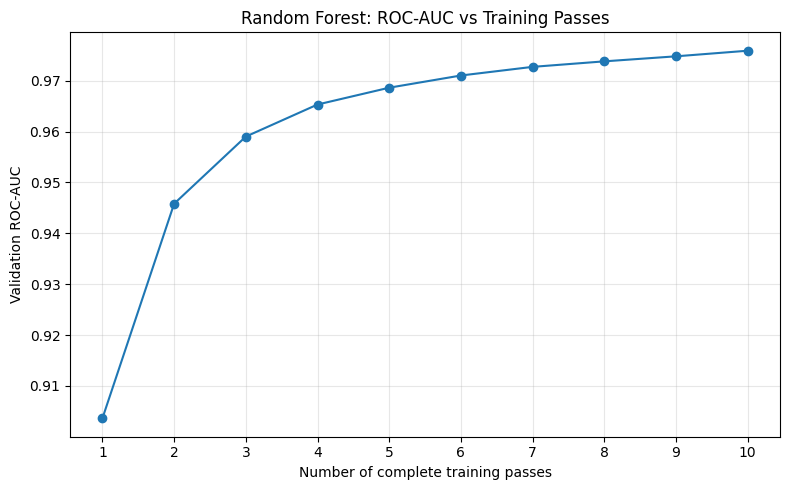

In [28]:
pass_roc_plot(df=rf_pass_results_df, model_name='Random Forest')

### XGBoost

In [29]:
#hyperparameter tuning
#keeping subsample=1 to ensure the meaning of a 'pass' is maintained
xgb_param_grid = {
    "max_depth": [
        2,
        4,
        6,
    ],
    "learning_rate": [
        0.05,
        0.1,
        0.3,
    ],
    "min_child_weight": [
        1,
        5,
    ],
    "reg_lambda": [
        1.0,
        10.0,
    ],
}

In [30]:
xgb_configurations = list(
    ParameterGrid(xgb_param_grid)
)

print(
    "XGBoost configurations:",
    len(xgb_configurations),
)

XGBoost configurations: 36


In [43]:
XGB_BEST_PARAMS={'learning_rate': 0.3, 'max_depth': 6, 'min_child_weight': 5, 'reg_lambda': 10.0}

In [33]:
##XGBoost’s native xgb.train function accepts a previous booster through xgb_model, allowing training to continue from an already built model
#creating XGBoost's internal data structures:
feature_names = [
    str(column)
    for column in X_train.columns
]

dtrain = xgb.DMatrix(
    X_train_np,
    label=y_train_bin,
    feature_names=feature_names,
)

dval = xgb.DMatrix(
    X_val_np,
    label=y_val_bin,
    feature_names=feature_names,
)

In [34]:
xgb_native_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",

    "max_depth":
        int(XGB_BEST_PARAMS["max_depth"]),

    # Native XGBoost commonly calls learning_rate "eta".
    "eta":
        float(XGB_BEST_PARAMS["learning_rate"]),

    "min_child_weight":
        float(XGB_BEST_PARAMS["min_child_weight"]),

    # Native parameter name corresponding to reg_lambda.
    "lambda":
        float(XGB_BEST_PARAMS["reg_lambda"]),

    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "num_parallel_tree": 1,

    "seed": 5,
    "verbosity": 0,
}

In [35]:
#adding one boosting round per loop:
xgb_pass_records = []

booster = None
cumulative_training_seconds = 0.0
n_training_rows = len(X_train_np)

for boosting_round in CHECKPOINTS:
    training_start = time.perf_counter()

    booster = xgb.train(
        params=xgb_native_params,
        dtrain=dtrain,

        # Add exactly one new boosting round.
        num_boost_round=1,

        # Continue from the existing booster.
        xgb_model=booster,

        verbose_eval=False,
    )

    round_training_seconds = (
        time.perf_counter() - training_start
    )

    cumulative_training_seconds += (
        round_training_seconds
    )

    actual_rounds = booster.num_boosted_rounds()

    if actual_rounds != boosting_round:
        raise RuntimeError(
            f"Expected {boosting_round} boosted rounds, "
            f"but booster reports {actual_rounds}."
        )

    probabilities = booster.predict(dval)

    evaluation = evaluate_binary_probabilities(
        y_val_bin,
        probabilities,
    )

    nominal_rows_processed = (
        boosting_round * n_training_rows
    )

    xgb_pass_records.append({
        "model": "XGBoost",
        "pass": boosting_round,
        "native_unit": "boosting rounds",
        "rows_processed": nominal_rows_processed,
        "roc_auc": evaluation["roc_auc"],
        "brier_score": evaluation["brier_score"],
        "probability_rmse":
            evaluation["probability_rmse"],
        "unique_probabilities":
            evaluation["unique_probabilities"],
        "pass_training_seconds":
            round_training_seconds,
        "cumulative_training_seconds":
            cumulative_training_seconds,
        "boosting_rounds": actual_rounds,
    })

    print(
        f"XGB pass {boosting_round:>2} | "
        f"AUC={evaluation['roc_auc']:.6f} | "
        f"RMSE={evaluation['probability_rmse']:.6f} | "
        f"rounds={actual_rounds:>2} | "
        f"nominal rows={nominal_rows_processed:,} | "
        f"time={cumulative_training_seconds:.2f}s"
    )

XGB pass  1 | AUC=0.941158 | RMSE=0.368246 | rounds= 1 | nominal rows=78,038 | time=0.15s
XGB pass  2 | AUC=0.955772 | RMSE=0.321805 | rounds= 2 | nominal rows=156,076 | time=0.17s
XGB pass  3 | AUC=0.961863 | RMSE=0.293356 | rounds= 3 | nominal rows=234,114 | time=0.20s
XGB pass  4 | AUC=0.965347 | RMSE=0.275246 | rounds= 4 | nominal rows=312,152 | time=0.23s
XGB pass  5 | AUC=0.967982 | RMSE=0.262970 | rounds= 5 | nominal rows=390,190 | time=0.25s
XGB pass  6 | AUC=0.969471 | RMSE=0.254922 | rounds= 6 | nominal rows=468,228 | time=0.30s
XGB pass  7 | AUC=0.970635 | RMSE=0.249696 | rounds= 7 | nominal rows=546,266 | time=0.32s
XGB pass  8 | AUC=0.972369 | RMSE=0.244237 | rounds= 8 | nominal rows=624,304 | time=0.35s
XGB pass  9 | AUC=0.973534 | RMSE=0.240258 | rounds= 9 | nominal rows=702,342 | time=0.38s
XGB pass 10 | AUC=0.974722 | RMSE=0.236590 | rounds=10 | nominal rows=780,380 | time=0.41s


In [36]:
xgb_pass_results_df = pd.DataFrame(
    xgb_pass_records
)

display(xgb_pass_results_df)

xgb_pass_results_df.to_csv(
    "MiniBooNE dataset outputs/xgboost_pass_results.csv",
    index=False,
)

,model,pass,native_unit,rows_processed,roc_auc,brier_score,probability_rmse,unique_probabilities,pass_training_seconds,cumulative_training_seconds,boosting_rounds
0,XGBoost,1,boosting rounds,78038,0.941158,0.135605,0.368246,61,0.146705,0.146705,1
1,XGBoost,2,boosting rounds,156076,0.955772,0.103558,0.321805,764,0.025868,0.172573,2
2,XGBoost,3,boosting rounds,234114,0.961863,0.086058,0.293356,2734,0.025720,0.198293,3
3,XGBoost,4,boosting rounds,312152,0.965347,0.075760,0.275246,4907,0.027178,0.225472,4
4,XGBoost,5,boosting rounds,390190,0.967982,0.069153,0.262970,7210,0.028415,0.253887,5
5,XGBoost,6,boosting rounds,468228,0.969471,0.064985,0.254922,9772,0.041156,0.295042,6
6,XGBoost,7,boosting rounds,546266,0.970635,0.062348,0.249696,11514,0.027251,0.322293,7
7,XGBoost,8,boosting rounds,624304,0.972369,0.059652,0.244237,13493,0.028088,0.350381,8
8,XGBoost,9,boosting rounds,702342,0.973534,0.057724,0.240258,14695,0.028760,0.379141,9
9,XGBoost,10,boosting rounds,780380,0.974722,0.055975,0.236590,16066,0.030262,0.409403,10


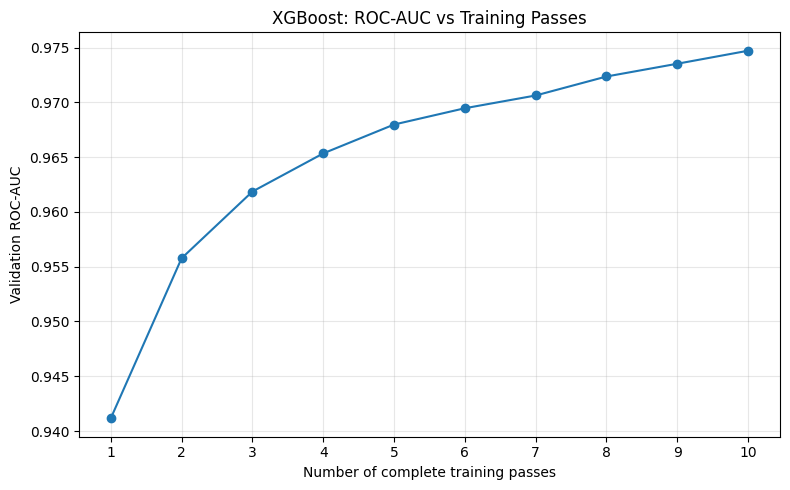

In [37]:
pass_roc_plot(df=xgb_pass_results_df, model_name='XGBoost')

### Combining comparison of all three models:

In [38]:
comparison_results_df = pd.concat(
    [
        ht_pass_results_df,
        rf_pass_results_df,
        xgb_pass_results_df,
    ],
    ignore_index=True,
    sort=False,
)

comparison_results_df.to_csv(
    "MiniBooNE dataset outputs/all_models_pass_results.csv",
    index=False,
)

display(
    comparison_results_df[
        [
            "model",
            "pass",
            "roc_auc",
            "probability_rmse",
            "cumulative_training_seconds",
        ]
    ]
)

,model,pass,roc_auc,probability_rmse,cumulative_training_seconds
0,Hoeffding Tree,1,0.687026,0.392473,1.696764
1,Hoeffding Tree,2,0.687026,0.392473,3.104676
2,Hoeffding Tree,3,0.687026,0.392473,4.472856
3,Hoeffding Tree,4,0.687026,0.392472,6.150143
4,Hoeffding Tree,5,0.687026,0.392472,7.631869
5,Hoeffding Tree,6,0.687026,0.392472,8.975272
6,Hoeffding Tree,7,0.687026,0.392472,10.495568
7,Hoeffding Tree,8,0.687026,0.392472,12.017454
8,Hoeffding Tree,9,0.687026,0.392472,13.408288
9,Hoeffding Tree,10,0.687026,0.392472,14.875050


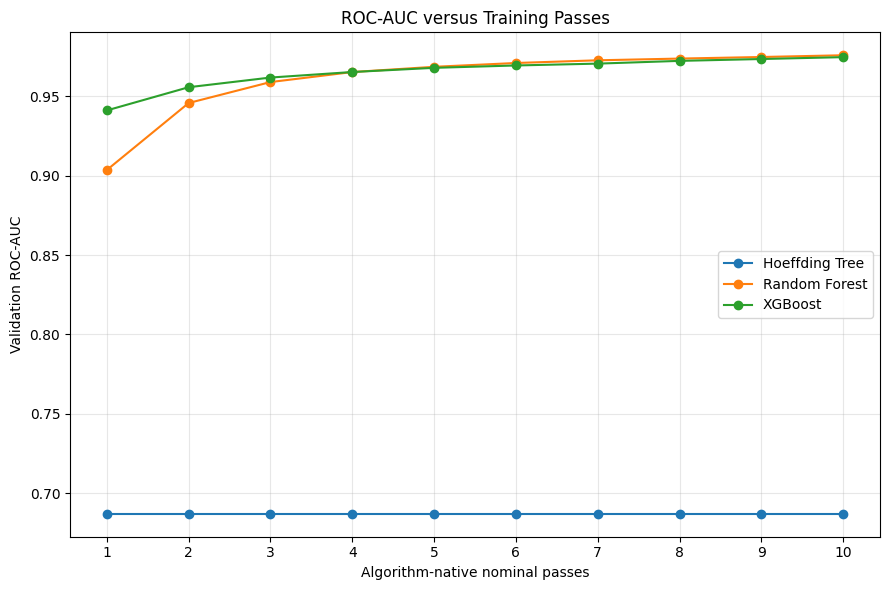

In [39]:
plt.figure(figsize=(9, 6))

for model_name, group in comparison_results_df.groupby(
    "model"
):
    ordered_group = group.sort_values("pass")

    plt.plot(
        ordered_group["pass"],
        ordered_group["roc_auc"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Algorithm-native nominal passes")
plt.ylabel("Validation ROC-AUC")
plt.title("ROC-AUC versus Training Passes")
plt.xticks(CHECKPOINTS)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

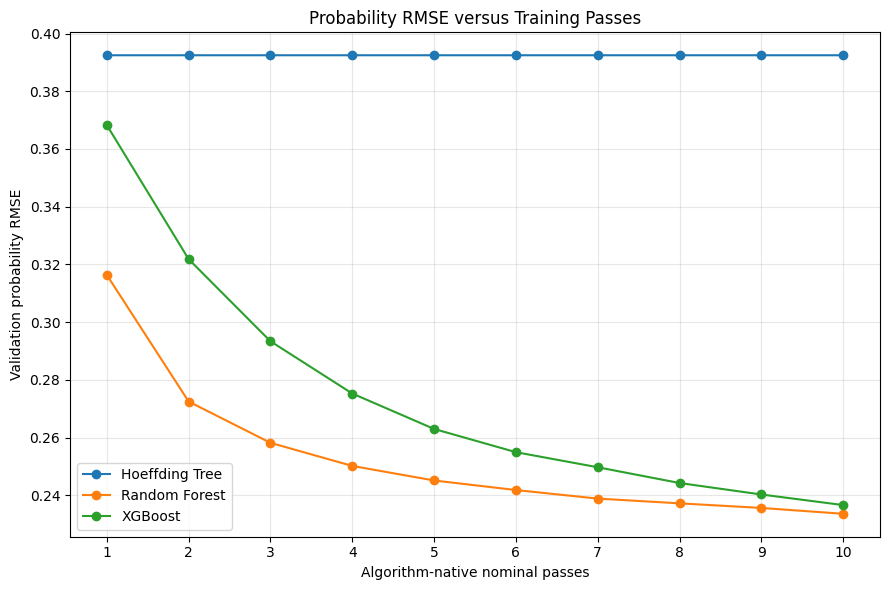

In [40]:
plt.figure(figsize=(9, 6))

for model_name, group in comparison_results_df.groupby(
    "model"
):
    ordered_group = group.sort_values("pass")

    plt.plot(
        ordered_group["pass"],
        ordered_group["probability_rmse"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Algorithm-native nominal passes")
plt.ylabel("Validation probability RMSE")
plt.title("Probability RMSE versus Training Passes")
plt.xticks(CHECKPOINTS)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

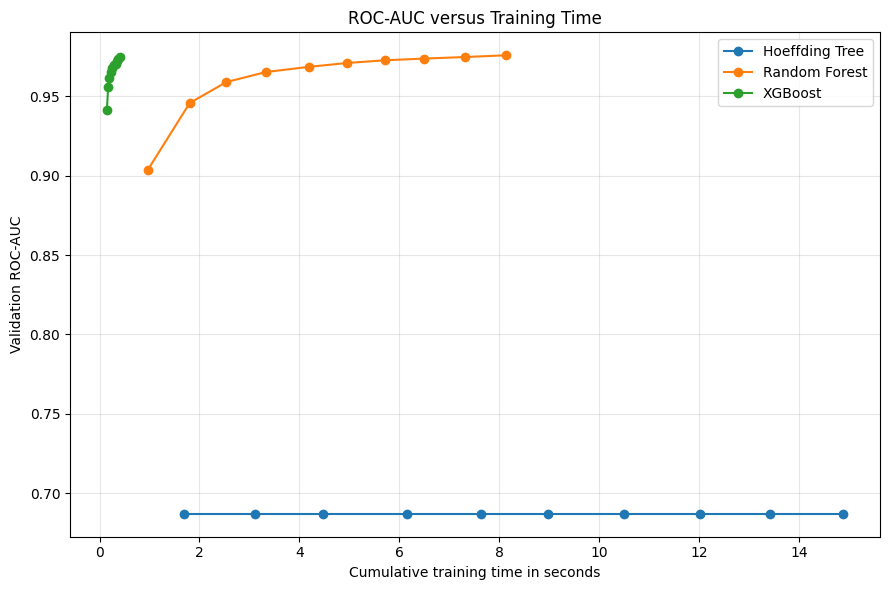

In [41]:
plt.figure(figsize=(9, 6))

for model_name, group in comparison_results_df.groupby(
    "model"
):
    ordered_group = group.sort_values(
        "cumulative_training_seconds"
    )

    plt.plot(
        ordered_group["cumulative_training_seconds"],
        ordered_group["roc_auc"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Cumulative training time in seconds")
plt.ylabel("Validation ROC-AUC")
plt.title("ROC-AUC versus Training Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()